In [18]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import pandas as pd
url = '/content/drive/MyDrive/AIL303m/cardio.csv'
df = pd.read_csv(url)
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [2]:
df.drop(columns = 'Unnamed: 0', axis = 0, inplace = True)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


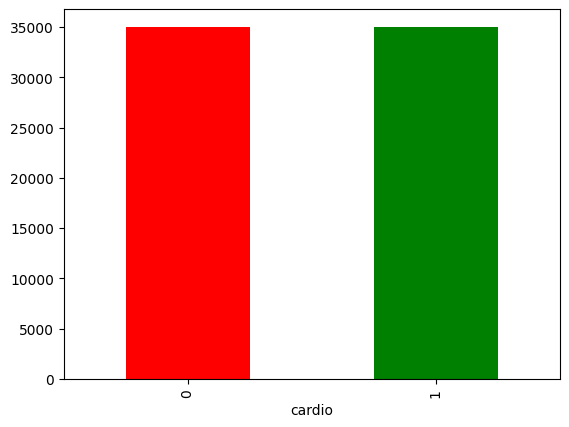

In [4]:
import matplotlib.pyplot as plt
y_col = 'cardio'
df[y_col].value_counts().plot.bar(color=['red','green'])
plt.show()

In [5]:
df.id.is_unique

True

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit
strat_shuf_split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.3, random_state = 42)
train_idx, test_idx = next(strat_shuf_split.split(df.drop(y_col, axis=1), df[y_col]))
X_train = df.drop(y_col, axis = 1).iloc[train_idx,:]
Y_train = df[y_col].iloc[train_idx]
X_test = df.drop(y_col, axis = 1).iloc[test_idx,:]
Y_test = df[y_col].iloc[test_idx]

In [8]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((49000, 12), (49000,), (21000, 12), (21000,))

In [9]:
Y_train.value_counts(normalize = True)

,proportion
cardio,
0,0.500306
1,0.499694


In [10]:
Y_test.value_counts(normalize = True)

,proportion
cardio,
0,0.500286
1,0.499714


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

class_weight = {}
# Assign weight of class 0 to be 0.29
class_weight[0] = 0.29
# Assign weight of class 1 to be 0.71
class_weight[1] = 0.71
model_lr = LogisticRegression (random_state = 123,
                               max_iter = 1000,
                               class_weight = class_weight)

model_lr.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight={0: 0.29, 1: 0.71}, max_iter=1000,
                   random_state=123)

In [16]:
preds_lr = model_lr.predict(X_test)

In [17]:
print(classification_report(Y_test, preds_lr))

              precision    recall  f1-score   support

           0       0.81      0.28      0.42     10506
           1       0.56      0.93      0.70     10494

    accuracy                           0.61     21000
   macro avg       0.69      0.61      0.56     21000
weighted avg       0.69      0.61      0.56     21000



In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import zero_one_loss
import numpy as np

# Train a Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, Y_train)

# Make predictions
preds_gbc = gbc.predict(X_test)

# Calculate error rate for different numbers of estimators
error_df = pd.DataFrame(np.zeros((gbc.estimators_.shape[0], 1)), columns=['error rate'])
for i, preds in enumerate(gbc.staged_predict(X_test)):
    error_df.iloc[i] = zero_one_loss(Y_test, preds)

In [31]:
print(classification_report(preds_gbc, Y_test))

              precision    recall  f1-score   support

           0       0.77      0.72      0.74     11261
           1       0.70      0.75      0.72      9739

    accuracy                           0.73     21000
   macro avg       0.73      0.73      0.73     21000
weighted avg       0.74      0.73      0.73     21000



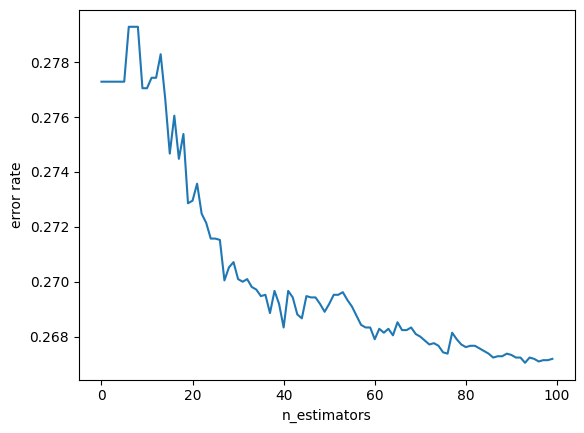

In [32]:
plt.plot(error_df)
plt.xlabel('n_estimators')
plt.ylabel('error rate')
plt.show()

In [26]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression


estimators = [('SVM', SVC(random_state = 42)), ('KNN', KNeighborsClassifier()), ('dt',DecisionTreeClassifier())]
clf = StackingClassifier(estimators = estimators, final_estimator = LogisticRegression())
clf.fit(X_train, Y_train)

StackingClassifier(estimators=[('SVM', SVC(random_state=42)),
                               ('KNN', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier())],
                   final_estimator=LogisticRegression())

In [27]:
StackingClassifier(estimators = [('SVM', SVC(random_state = 42)), ('KNN', KNeighborsClassifier()), ('dt',DecisionTreeClassifier())],
                   final_estimator = LogisticRegression())

StackingClassifier(estimators=[('SVM', SVC(random_state=42)),
                               ('KNN', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier())],
                   final_estimator=LogisticRegression())

In [28]:
preds_clf = clf.predict(X_test)

In [29]:
print(classification_report(preds_clf, Y_test))

              precision    recall  f1-score   support

           0       0.69      0.65      0.67     11213
           1       0.63      0.67      0.65      9787

    accuracy                           0.66     21000
   macro avg       0.66      0.66      0.66     21000
weighted avg       0.66      0.66      0.66     21000

